# [17.1] Checkpoint Archaeology and Mechanism Emergence

> **Notebooks: [exercises](./17.1_Checkpoint_Archaeology_and_Mechanism_Emergence_exercises.ipynb) | [solutions](./17.1_Checkpoint_Archaeology_and_Mechanism_Emergence_solutions.ipynb)**

By the end of this notebook, you will have shown that a tiny checkpointed model develops a measurable modular-addition mechanism during training, because a Fourier legality metric rises with task performance while random-label and random-mechanism controls fail.

The point is not to stare at a loss curve and narrate a story. The point is to build a finite model organism where you can save checkpoints, reload them, measure a mathematically meaningful mechanism, and perform an intervention that makes the mechanism necessary.

The model organism is deliberately small: a two-token MLP trained on the complete mod-13 addition table. That keeps the evidence exact enough for a notebook, while still giving you a real train/save/reload loop and a real Fourier mechanism metric inspired by the original ARENA modular arithmetic section.

## Learning Objectives

By the end, you should be able to:

- construct the complete finite mod-13 addition domain and a noiseless ground-truth logit table;
- identify the Fourier modes that exactly encode the addition rule;
- distinguish a real mechanism score from a same-size random Fourier mask;
- train a tiny checkpointed model and recompute every metric only after checkpoint reload;
- compare early, mid, and late checkpoint interventions by keeping or ablating legal Fourier modes;
- reject random-label and random-mechanism controls without weakening the claim into a vague training-curve story.

<img src="../../instructions/assets/checkpoint_archaeology_validation_loop.svg" width="760">

In [1]:
from __future__ import annotations

import json
import sys
import tempfile
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import torch as t
import torch.nn.functional as F
from IPython.display import Markdown, display

chapter = "chapter17_training_dynamics"
section = "part1_checkpoint_archaeology"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
exercises_dir = root_dir / chapter / "exercises"
section_dir = exercises_dir / section
assets_dir = root_dir / chapter / "instructions" / "assets"

if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))
if str(exercises_dir) not in sys.path:
    sys.path.append(str(exercises_dir))

import part1_checkpoint_archaeology.tests as tests

from arena_ext.training_dynamics import (
    developmental_comparison_report,
    first_threshold_crossing,
    mechanism_emergence_report,
    monotonicity_violations,
    phase_transition_report,
    random_control_report,
    stable_threshold_step,
    toy_training_trajectories,
)

MODULAR_ARCHAEOLOGY_MODULUS = 13
MODULAR_ARCHAEOLOGY_EMBED_DIM = 32
MODULAR_ARCHAEOLOGY_HIDDEN_DIM = 96
MODULAR_ARCHAEOLOGY_LR = 5e-3
MODULAR_ARCHAEOLOGY_STEPS = 180
MODULAR_ARCHAEOLOGY_CHECKPOINT_STEPS = [0, 1, 2, 4, 8, 12, 16, 24, 32, 48, 64, 96, 128, 180]
MODULAR_ARCHAEOLOGY_ACCURACY_THRESHOLD = 0.90
MODULAR_ARCHAEOLOGY_MECHANISM_THRESHOLD = 0.50
MODULAR_ARCHAEOLOGY_MIN_CONSECUTIVE = 2

t.manual_seed(0)

## Cold Open: What Would Count As Emergence?

For modular addition, the correct logit table is not arbitrary. If the output token is `c`, then the exact rule is high when `c = a + b mod p`. In a 3D Fourier basis over `(a, b, c)`, this rule lives on a tiny set of legal frequencies:

`k_a = k_b = -k_c mod p`.

That gives us a mechanism metric before we train anything: what fraction of centered logit-table Fourier power lies in those legal modes? A useful checkpoint archaeology claim should show that this fraction rises, that it tracks performance, and that ablating those modes causally damages the trained checkpoint.

### Exercise 1 - Build the Finite Model Organism

> ```yaml
> Difficulty: medium
> Importance: high
> Expected time: 10 minutes
> ```

Implement the complete mod-addition dataset and a noiseless exact logit table. This is the ground truth you will use to check the mechanism metric before trusting it on a trained model.

In [2]:
def make_modular_addition_dataset(
    *,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
    device: str | t.device = "cpu",
) -> tuple[t.Tensor, t.Tensor]:
    """Return every pair (a, b) and the label (a + b) mod p."""

    device = t.device(device)
    pairs = t.tensor(
        [[left, right] for left in range(modulus) for right in range(modulus)],
        dtype=t.long,
        device=device,
    )
    labels = (pairs[:, 0] + pairs[:, 1]) % modulus
    return pairs, labels

def exact_addition_logits(
    *,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
    correct_logit: float = 5.0,
    incorrect_logit: float = -5.0,
    device: str | t.device = "cpu",
) -> t.Tensor:
    """A noiseless finite-table logit tensor for the exact addition rule."""

    _, labels = make_modular_addition_dataset(modulus=modulus, device=device)
    logits = t.full((modulus * modulus, modulus), incorrect_logit, device=t.device(device))
    logits[t.arange(labels.numel(), device=labels.device), labels] = correct_logit
    return logits

tests.test_make_modular_addition_dataset_has_exact_finite_table(make_modular_addition_dataset)

All tests in `test_make_modular_addition_dataset_has_exact_finite_table` passed!


<details>
<summary>Expected output</summary>

```text
All tests in `test_make_modular_addition_dataset_has_exact_finite_table` passed!
Example: (7 + 11) mod 13 = 5
```

</details>

<details>
<summary>Help</summary>

Enumerate all pairs in row-major order: for each `a`, loop over every `b`. The labels are `(pairs[:, 0] + pairs[:, 1]) % modulus`.

</details>

<details>
<summary>Interpretation</summary>

This exact table is your toy ground truth. Any later claim about emergence is scoped to these 169 inputs; it is not an OOD generalization claim.

</details>

<details>
<summary>Solution</summary>

```python
def make_modular_addition_dataset(
    *,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
    device: str | t.device = "cpu",
) -> tuple[t.Tensor, t.Tensor]:
    """Return every pair (a, b) and the label (a + b) mod p."""

    device = t.device(device)
    pairs = t.tensor(
        [[left, right] for left in range(modulus) for right in range(modulus)],
        dtype=t.long,
        device=device,
    )
    labels = (pairs[:, 0] + pairs[:, 1]) % modulus
    return pairs, labels

def exact_addition_logits(
    *,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
    correct_logit: float = 5.0,
    incorrect_logit: float = -5.0,
    device: str | t.device = "cpu",
) -> t.Tensor:
    """A noiseless finite-table logit tensor for the exact addition rule."""

    _, labels = make_modular_addition_dataset(modulus=modulus, device=device)
    logits = t.full((modulus * modulus, modulus), incorrect_logit, device=t.device(device))
    logits[t.arange(labels.numel(), device=labels.device), labels] = correct_logit
    return logits
```

</details>

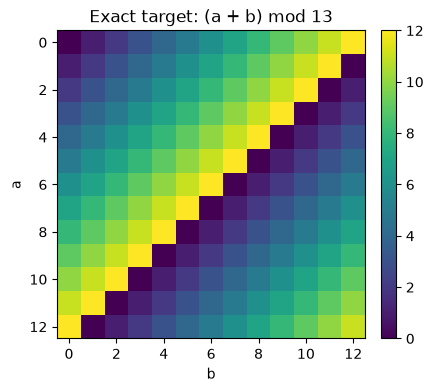

Example: (7 + 11) mod 13 = 5


In [3]:
pairs, labels = make_modular_addition_dataset(modulus=MODULAR_ARCHAEOLOGY_MODULUS, device="cpu")
addition_table = labels.reshape(MODULAR_ARCHAEOLOGY_MODULUS, MODULAR_ARCHAEOLOGY_MODULUS)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(addition_table, cmap="viridis")
ax.set_title("Exact target: (a + b) mod 13")
ax.set_xlabel("b")
ax.set_ylabel("a")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()
print("Example: (7 + 11) mod 13 =", int(addition_table[7, 11].item()))

### Exercise 2 - Define the Fourier Mechanism Metric

> ```yaml
> Difficulty: hard
> Importance: high
> Expected time: 25 minutes
> ```

The exact rule `c = a + b mod p` has a sparse Fourier signature over the logit cube indexed by `(a, b, c)`. Build the legal-mode mask, a same-size random mask, and a power-fraction metric.

In [4]:
def addition_fourier_mask(
    *,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
    device: str | t.device = "cpu",
) -> t.Tensor:
    """Mask Fourier modes satisfying k_a = k_b = -k_c mod p, excluding DC."""

    mask = t.zeros((modulus, modulus, modulus), dtype=t.bool, device=t.device(device))
    for output_frequency in range(1, modulus):
        input_frequency = (-output_frequency) % modulus
        mask[input_frequency, input_frequency, output_frequency] = True
    return mask

def random_fourier_mask(
    *,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
    seed: int = 0,
    device: str | t.device = "cpu",
) -> t.Tensor:
    """Sample a same-size conjugate-symmetric mask that is not the addition mask."""

    device = t.device(device)
    legal = addition_fourier_mask(modulus=modulus, device="cpu")
    target_count = int(legal.sum().item())
    if target_count % 2 != 0:
        raise ValueError("random mask construction expects an even non-DC mode count.")

    generator = t.Generator(device="cpu").manual_seed(seed)
    mask = t.zeros_like(legal)
    attempts = 0
    while int(mask.sum().item()) < target_count:
        attempts += 1
        if attempts > 10_000:
            raise RuntimeError("could not sample a valid random Fourier mask.")
        triple = t.randint(0, modulus, (3,), generator=generator).tolist()
        conj = [(-value) % modulus for value in triple]
        if triple == [0, 0, 0]:
            continue
        if legal[triple[0], triple[1], triple[2]] or legal[conj[0], conj[1], conj[2]]:
            continue
        if mask[triple[0], triple[1], triple[2]] or mask[conj[0], conj[1], conj[2]]:
            continue
        mask[triple[0], triple[1], triple[2]] = True
        mask[conj[0], conj[1], conj[2]] = True
    return mask.to(device)

def _logits_to_centered_cube(logits: t.Tensor, *, modulus: int) -> tuple[t.Tensor, t.Tensor]:
    logits = t.as_tensor(logits).float()
    expected_shape = (modulus * modulus, modulus)
    if tuple(logits.shape) != expected_shape:
        raise ValueError(f"logits must have shape {expected_shape}, got {tuple(logits.shape)}.")
    cube = logits.reshape(modulus, modulus, modulus)
    output_mean = cube.mean(dim=-1, keepdim=True)
    return cube - output_mean, output_mean

def fourier_power_fraction(
    logits: t.Tensor,
    mask: t.Tensor,
    *,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
) -> float:
    """Return the fraction of centered logit-table Fourier power inside mask."""

    centered, _ = _logits_to_centered_cube(logits, modulus=modulus)
    mask = t.as_tensor(mask, dtype=t.bool, device=centered.device)
    if tuple(mask.shape) != (modulus, modulus, modulus):
        raise ValueError("mask must have shape (modulus, modulus, modulus).")
    coeffs = t.fft.fftn(centered, dim=(0, 1, 2))
    power = coeffs.abs().square()
    total_power = power.sum()
    if float(total_power.item()) == 0.0:
        return 0.0
    return float((power[mask].sum() / total_power).item())

def addition_mechanism_score(
    logits: t.Tensor,
    *,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
) -> float:
    """Fourier score for the legal mod-addition modes of a logit table."""

    return fourier_power_fraction(
        logits,
        addition_fourier_mask(modulus=modulus, device=logits.device),
        modulus=modulus,
    )

tests.test_addition_fourier_mask_identifies_exact_addition_rule(
    addition_fourier_mask,
    random_fourier_mask,
    fourier_power_fraction,
    exact_addition_logits,
)

All tests in `test_addition_fourier_mask_identifies_exact_addition_rule` passed!


<details>
<summary>Expected output</summary>

```text
All tests in `test_addition_fourier_mask_identifies_exact_addition_rule` passed!
legal addition Fourier score: 1.0
same-size random Fourier score: near 0.0
```

</details>

<details>
<summary>Help</summary>

For every nonzero output frequency `k_c`, the legal input frequencies are both `(-k_c) % p`. Remove the per-input output mean before taking the FFT, because adding the same scalar to every output logit cannot change the predicted class.

</details>

<details>
<summary>Interpretation</summary>

A high score means the logit table is using frequencies compatible with addition. The same-size random mask is the first control: if it also scores high, your metric is too broad.

</details>

<details>
<summary>Solution</summary>

```python
def addition_fourier_mask(
    *,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
    device: str | t.device = "cpu",
) -> t.Tensor:
    """Mask Fourier modes satisfying k_a = k_b = -k_c mod p, excluding DC."""

    mask = t.zeros((modulus, modulus, modulus), dtype=t.bool, device=t.device(device))
    for output_frequency in range(1, modulus):
        input_frequency = (-output_frequency) % modulus
        mask[input_frequency, input_frequency, output_frequency] = True
    return mask

def random_fourier_mask(
    *,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
    seed: int = 0,
    device: str | t.device = "cpu",
) -> t.Tensor:
    """Sample a same-size conjugate-symmetric mask that is not the addition mask."""

    device = t.device(device)
    legal = addition_fourier_mask(modulus=modulus, device="cpu")
    target_count = int(legal.sum().item())
    if target_count % 2 != 0:
        raise ValueError("random mask construction expects an even non-DC mode count.")

    generator = t.Generator(device="cpu").manual_seed(seed)
    mask = t.zeros_like(legal)
    attempts = 0
    while int(mask.sum().item()) < target_count:
        attempts += 1
        if attempts > 10_000:
            raise RuntimeError("could not sample a valid random Fourier mask.")
        triple = t.randint(0, modulus, (3,), generator=generator).tolist()
        conj = [(-value) % modulus for value in triple]
        if triple == [0, 0, 0]:
            continue
        if legal[triple[0], triple[1], triple[2]] or legal[conj[0], conj[1], conj[2]]:
            continue
        if mask[triple[0], triple[1], triple[2]] or mask[conj[0], conj[1], conj[2]]:
            continue
        mask[triple[0], triple[1], triple[2]] = True
        mask[conj[0], conj[1], conj[2]] = True
    return mask.to(device)

def _logits_to_centered_cube(logits: t.Tensor, *, modulus: int) -> tuple[t.Tensor, t.Tensor]:
    logits = t.as_tensor(logits).float()
    expected_shape = (modulus * modulus, modulus)
    if tuple(logits.shape) != expected_shape:
        raise ValueError(f"logits must have shape {expected_shape}, got {tuple(logits.shape)}.")
    cube = logits.reshape(modulus, modulus, modulus)
    output_mean = cube.mean(dim=-1, keepdim=True)
    return cube - output_mean, output_mean

def fourier_power_fraction(
    logits: t.Tensor,
    mask: t.Tensor,
    *,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
) -> float:
    """Return the fraction of centered logit-table Fourier power inside mask."""

    centered, _ = _logits_to_centered_cube(logits, modulus=modulus)
    mask = t.as_tensor(mask, dtype=t.bool, device=centered.device)
    if tuple(mask.shape) != (modulus, modulus, modulus):
        raise ValueError("mask must have shape (modulus, modulus, modulus).")
    coeffs = t.fft.fftn(centered, dim=(0, 1, 2))
    power = coeffs.abs().square()
    total_power = power.sum()
    if float(total_power.item()) == 0.0:
        return 0.0
    return float((power[mask].sum() / total_power).item())

def addition_mechanism_score(
    logits: t.Tensor,
    *,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
) -> float:
    """Fourier score for the legal mod-addition modes of a logit table."""

    return fourier_power_fraction(
        logits,
        addition_fourier_mask(modulus=modulus, device=logits.device),
        modulus=modulus,
    )
```

</details>

In [5]:
exact_logits = exact_addition_logits(modulus=MODULAR_ARCHAEOLOGY_MODULUS, device="cpu")
legal_mask = addition_fourier_mask(modulus=MODULAR_ARCHAEOLOGY_MODULUS, device="cpu")
random_mask = random_fourier_mask(modulus=MODULAR_ARCHAEOLOGY_MODULUS, seed=17, device="cpu")
print("legal addition Fourier score:", round(fourier_power_fraction(exact_logits, legal_mask), 4))
print("same-size random Fourier score:", round(fourier_power_fraction(exact_logits, random_mask), 4))

legal addition Fourier score: 1.0
same-size random Fourier score: 0.0


### Exercise 3 - Make the Mechanism Causal on Exact Ground Truth

> ```yaml
> Difficulty: hard
> Importance: high
> Expected time: 20 minutes
> ```

Now turn the metric into an intervention. Keep only legal Fourier modes, or ablate legal Fourier modes, then invert the FFT and measure table accuracy.

In [6]:
def project_logits_to_fourier_mask(
    logits: t.Tensor,
    mask: t.Tensor,
    *,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
    keep: bool = True,
) -> t.Tensor:
    """Keep or ablate selected Fourier modes, then invert back to logits."""

    centered, output_mean = _logits_to_centered_cube(logits, modulus=modulus)
    mask = t.as_tensor(mask, dtype=t.bool, device=centered.device)
    coeffs = t.fft.fftn(centered, dim=(0, 1, 2))
    filtered = t.where(mask, coeffs, t.zeros_like(coeffs)) if keep else t.where(
        mask,
        t.zeros_like(coeffs),
        coeffs,
    )
    intervened = t.fft.ifftn(filtered, dim=(0, 1, 2)).real + output_mean
    return intervened.reshape(modulus * modulus, modulus)

def accuracy_from_logits(logits: t.Tensor, labels: t.Tensor) -> float:
    labels = t.as_tensor(labels, device=logits.device)
    return float(logits.argmax(dim=-1).eq(labels).float().mean().item())

def fourier_intervention_report(
    logits: t.Tensor,
    labels: t.Tensor,
    *,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
    random_seed: int = 0,
) -> dict[str, float]:
    """Compare legal addition modes with a same-size random Fourier mask."""

    legal = addition_fourier_mask(modulus=modulus, device=logits.device)
    random_mask = random_fourier_mask(modulus=modulus, seed=random_seed, device=logits.device)
    legal_only = project_logits_to_fourier_mask(logits, legal, modulus=modulus, keep=True)
    legal_ablated = project_logits_to_fourier_mask(logits, legal, modulus=modulus, keep=False)
    random_only = project_logits_to_fourier_mask(logits, random_mask, modulus=modulus, keep=True)
    random_ablated = project_logits_to_fourier_mask(
        logits,
        random_mask,
        modulus=modulus,
        keep=False,
    )
    original_accuracy = accuracy_from_logits(logits, labels)
    legal_ablated_accuracy = accuracy_from_logits(legal_ablated, labels)
    random_ablated_accuracy = accuracy_from_logits(random_ablated, labels)
    return {
        "original_accuracy": original_accuracy,
        "addition_fourier_score": fourier_power_fraction(logits, legal, modulus=modulus),
        "random_fourier_score": fourier_power_fraction(logits, random_mask, modulus=modulus),
        "legal_only_accuracy": accuracy_from_logits(legal_only, labels),
        "legal_ablated_accuracy": legal_ablated_accuracy,
        "random_only_accuracy": accuracy_from_logits(random_only, labels),
        "random_ablated_accuracy": random_ablated_accuracy,
        "legal_ablation_drop": original_accuracy - legal_ablated_accuracy,
        "random_ablation_drop": original_accuracy - random_ablated_accuracy,
    }

tests.test_fourier_intervention_report_is_causal_on_exact_table(
    fourier_intervention_report,
    exact_addition_logits,
    make_modular_addition_dataset,
)

All tests in `test_fourier_intervention_report_is_causal_on_exact_table` passed!


<details>
<summary>Expected output</summary>

```text
All tests in `test_fourier_intervention_report_is_causal_on_exact_table` passed!
legal_only_accuracy: 1.0000
legal_ablated_accuracy: <= 0.1000
random_only_accuracy: near chance
```

</details>

<details>
<summary>Help</summary>

Use `torch.fft.fftn` on the centered cube. For a keep intervention, zero every coefficient outside the mask. For an ablation intervention, zero every coefficient inside the mask.

</details>

<details>
<summary>Interpretation</summary>

On exact ground truth, legal modes are sufficient and necessary. This gives you a toy oracle before you inspect learned checkpoints.

</details>

<details>
<summary>Solution</summary>

```python
def project_logits_to_fourier_mask(
    logits: t.Tensor,
    mask: t.Tensor,
    *,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
    keep: bool = True,
) -> t.Tensor:
    """Keep or ablate selected Fourier modes, then invert back to logits."""

    centered, output_mean = _logits_to_centered_cube(logits, modulus=modulus)
    mask = t.as_tensor(mask, dtype=t.bool, device=centered.device)
    coeffs = t.fft.fftn(centered, dim=(0, 1, 2))
    filtered = t.where(mask, coeffs, t.zeros_like(coeffs)) if keep else t.where(
        mask,
        t.zeros_like(coeffs),
        coeffs,
    )
    intervened = t.fft.ifftn(filtered, dim=(0, 1, 2)).real + output_mean
    return intervened.reshape(modulus * modulus, modulus)

def accuracy_from_logits(logits: t.Tensor, labels: t.Tensor) -> float:
    labels = t.as_tensor(labels, device=logits.device)
    return float(logits.argmax(dim=-1).eq(labels).float().mean().item())

def fourier_intervention_report(
    logits: t.Tensor,
    labels: t.Tensor,
    *,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
    random_seed: int = 0,
) -> dict[str, float]:
    """Compare legal addition modes with a same-size random Fourier mask."""

    legal = addition_fourier_mask(modulus=modulus, device=logits.device)
    random_mask = random_fourier_mask(modulus=modulus, seed=random_seed, device=logits.device)
    legal_only = project_logits_to_fourier_mask(logits, legal, modulus=modulus, keep=True)
    legal_ablated = project_logits_to_fourier_mask(logits, legal, modulus=modulus, keep=False)
    random_only = project_logits_to_fourier_mask(logits, random_mask, modulus=modulus, keep=True)
    random_ablated = project_logits_to_fourier_mask(
        logits,
        random_mask,
        modulus=modulus,
        keep=False,
    )
    original_accuracy = accuracy_from_logits(logits, labels)
    legal_ablated_accuracy = accuracy_from_logits(legal_ablated, labels)
    random_ablated_accuracy = accuracy_from_logits(random_ablated, labels)
    return {
        "original_accuracy": original_accuracy,
        "addition_fourier_score": fourier_power_fraction(logits, legal, modulus=modulus),
        "random_fourier_score": fourier_power_fraction(logits, random_mask, modulus=modulus),
        "legal_only_accuracy": accuracy_from_logits(legal_only, labels),
        "legal_ablated_accuracy": legal_ablated_accuracy,
        "random_only_accuracy": accuracy_from_logits(random_only, labels),
        "random_ablated_accuracy": random_ablated_accuracy,
        "legal_ablation_drop": original_accuracy - legal_ablated_accuracy,
        "random_ablation_drop": original_accuracy - random_ablated_accuracy,
    }
```

</details>

In [7]:
_, labels = make_modular_addition_dataset(modulus=MODULAR_ARCHAEOLOGY_MODULUS, device="cpu")
exact_report = fourier_intervention_report(exact_logits, labels, random_seed=3)
for key, value in exact_report.items():
    print(f"{key:>28}: {value:.4f}")

           original_accuracy: 1.0000
      addition_fourier_score: 1.0000
        random_fourier_score: 0.0000
         legal_only_accuracy: 1.0000
      legal_ablated_accuracy: 0.0473
        random_only_accuracy: 0.0769
     random_ablated_accuracy: 1.0000
         legal_ablation_drop: 0.9527
        random_ablation_drop: 0.0000


## The Tiny Checkpointed Model

We will use a small MLP with learned token embeddings for `a` and `b`. This is intentionally simpler than the one-layer transformer in the original grokking notebook; the mechanism evidence comes from the finite logit table and Fourier interventions, not from claiming a full transformer circuit.

In [8]:
class TinyModularAdditionMLP(t.nn.Module):
    """Tiny finite-table model organism for checkpoint archaeology."""

    def __init__(
        self,
        *,
        modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
        embed_dim: int = MODULAR_ARCHAEOLOGY_EMBED_DIM,
        hidden_dim: int = MODULAR_ARCHAEOLOGY_HIDDEN_DIM,
    ):
        super().__init__()
        self.modulus = modulus
        self.embed = t.nn.Embedding(modulus, embed_dim)
        self.mlp = t.nn.Sequential(
            t.nn.Linear(2 * embed_dim, hidden_dim),
            t.nn.GELU(),
            t.nn.Linear(hidden_dim, modulus),
        )

    def forward(self, input_pairs: t.Tensor) -> t.Tensor:
        embedded = self.embed(input_pairs)
        return self.mlp(embedded.flatten(start_dim=1))

### Exercise 4 - Train, Save, Reload, Then Measure

> ```yaml
> Difficulty: hard
> Importance: high
> Expected time: 30 minutes
> ```

Implement the archaeology loop. You must save real checkpoint files, reload each file into a fresh model, and compute accuracy, loss, the legal Fourier score, and the random-mask Fourier score from the reloaded model.

In [9]:
def checkpoint_logits_from_file(
    checkpoint_path: Path,
    *,
    device: str | t.device,
    input_pairs: t.Tensor,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
) -> t.Tensor:
    """Load one checkpoint file into a fresh model and return logits."""

    device = t.device(device)
    model = TinyModularAdditionMLP(modulus=modulus).to(device)
    checkpoint = t.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()
    with t.inference_mode():
        return model(input_pairs)

def train_save_reload_modular_checkpoints(
    *,
    checkpoint_dir: Path,
    device: str | t.device = "cpu",
    seed: int = 0,
    random_labels: bool = False,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
    steps: int = MODULAR_ARCHAEOLOGY_STEPS,
    checkpoint_steps: Iterable[int] = MODULAR_ARCHAEOLOGY_CHECKPOINT_STEPS,
) -> dict:
    """Train, save real checkpoints, reload each one, and compute metrics."""

    device = t.device(device)
    checkpoint_steps = sorted(set(int(step) for step in checkpoint_steps))
    if checkpoint_steps[0] != 0 or checkpoint_steps[-1] != steps:
        raise ValueError("checkpoint_steps must include 0 and steps.")
    t.manual_seed(seed)
    if device.type == "cuda":
        t.cuda.manual_seed_all(seed)

    input_pairs, true_labels = make_modular_addition_dataset(modulus=modulus, device=device)
    train_labels = true_labels
    if random_labels:
        generator = t.Generator(device=device).manual_seed(seed + 1000)
        train_labels = t.randint(
            0,
            modulus,
            true_labels.shape,
            generator=generator,
            device=device,
        )

    model = TinyModularAdditionMLP(modulus=modulus).to(device)
    optimizer = t.optim.AdamW(model.parameters(), lr=MODULAR_ARCHAEOLOGY_LR, weight_decay=1e-3)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_paths: list[Path] = []
    checkpoint_step_set = set(checkpoint_steps)

    for step in range(steps + 1):
        if step in checkpoint_step_set:
            path = checkpoint_dir / f"step_{step:04d}.pt"
            t.save(
                {
                    "step": step,
                    "model_state": model.state_dict(),
                    "random_labels": random_labels,
                    "modulus": modulus,
                    "seed": seed,
                },
                path,
            )
            checkpoint_paths.append(path)
        if step == steps:
            break
        optimizer.zero_grad(set_to_none=True)
        loss = F.cross_entropy(model(input_pairs), train_labels)
        loss.backward()
        optimizer.step()

    accuracies: list[float] = []
    losses: list[float] = []
    mechanism_scores: list[float] = []
    random_mechanism_scores: list[float] = []
    random_mask = random_fourier_mask(modulus=modulus, seed=seed + 7, device=device)
    for path in checkpoint_paths:
        logits = checkpoint_logits_from_file(
            path,
            device=device,
            input_pairs=input_pairs,
            modulus=modulus,
        )
        accuracies.append(accuracy_from_logits(logits, true_labels))
        losses.append(float(F.cross_entropy(logits, true_labels).item()))
        mechanism_scores.append(addition_mechanism_score(logits, modulus=modulus))
        random_mechanism_scores.append(
            fourier_power_fraction(logits, random_mask, modulus=modulus)
        )

    return {
        "steps": t.tensor(checkpoint_steps, dtype=t.long, device=device),
        "accuracies": t.tensor(accuracies, dtype=t.float32, device=device),
        "losses": t.tensor(losses, dtype=t.float32, device=device),
        "mechanism_scores": t.tensor(mechanism_scores, dtype=t.float32, device=device),
        "random_mechanism_scores": t.tensor(
            random_mechanism_scores,
            dtype=t.float32,
            device=device,
        ),
        "checkpoint_paths": checkpoint_paths,
        "checkpoint_count": len(checkpoint_paths),
        "checkpoint_total_bytes": sum(path.stat().st_size for path in checkpoint_paths),
        "random_labels": random_labels,
        "real_checkpoints_reloaded": True,
    }

tests.test_train_save_reload_modular_checkpoints_writes_real_files(
    train_save_reload_modular_checkpoints
)

All tests in `test_train_save_reload_modular_checkpoints_writes_real_files` passed!


<details>
<summary>Expected output</summary>

```text
All tests in `test_train_save_reload_modular_checkpoints_writes_real_files` passed!
accuracy: rises to 1.0 by the short run
addition Fourier score: rises strongly
random Fourier score: stays near zero
```

</details>

<details>
<summary>Help</summary>

Save a dictionary containing `model_state`, `step`, `random_labels`, `modulus`, and `seed`. The test checks file size and reload semantics because metrics kept only in memory are not checkpoint archaeology.

</details>

<details>
<summary>Interpretation</summary>

The metric is only trusted after reload. That is the habit you want before scaling to messy real training runs.

</details>

<details>
<summary>Solution</summary>

```python
def checkpoint_logits_from_file(
    checkpoint_path: Path,
    *,
    device: str | t.device,
    input_pairs: t.Tensor,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
) -> t.Tensor:
    """Load one checkpoint file into a fresh model and return logits."""

    device = t.device(device)
    model = TinyModularAdditionMLP(modulus=modulus).to(device)
    checkpoint = t.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()
    with t.inference_mode():
        return model(input_pairs)

def train_save_reload_modular_checkpoints(
    *,
    checkpoint_dir: Path,
    device: str | t.device = "cpu",
    seed: int = 0,
    random_labels: bool = False,
    modulus: int = MODULAR_ARCHAEOLOGY_MODULUS,
    steps: int = MODULAR_ARCHAEOLOGY_STEPS,
    checkpoint_steps: Iterable[int] = MODULAR_ARCHAEOLOGY_CHECKPOINT_STEPS,
) -> dict:
    """Train, save real checkpoints, reload each one, and compute metrics."""

    device = t.device(device)
    checkpoint_steps = sorted(set(int(step) for step in checkpoint_steps))
    if checkpoint_steps[0] != 0 or checkpoint_steps[-1] != steps:
        raise ValueError("checkpoint_steps must include 0 and steps.")
    t.manual_seed(seed)
    if device.type == "cuda":
        t.cuda.manual_seed_all(seed)

    input_pairs, true_labels = make_modular_addition_dataset(modulus=modulus, device=device)
    train_labels = true_labels
    if random_labels:
        generator = t.Generator(device=device).manual_seed(seed + 1000)
        train_labels = t.randint(
            0,
            modulus,
            true_labels.shape,
            generator=generator,
            device=device,
        )

    model = TinyModularAdditionMLP(modulus=modulus).to(device)
    optimizer = t.optim.AdamW(model.parameters(), lr=MODULAR_ARCHAEOLOGY_LR, weight_decay=1e-3)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_paths: list[Path] = []
    checkpoint_step_set = set(checkpoint_steps)

    for step in range(steps + 1):
        if step in checkpoint_step_set:
            path = checkpoint_dir / f"step_{step:04d}.pt"
            t.save(
                {
                    "step": step,
                    "model_state": model.state_dict(),
                    "random_labels": random_labels,
                    "modulus": modulus,
                    "seed": seed,
                },
                path,
            )
            checkpoint_paths.append(path)
        if step == steps:
            break
        optimizer.zero_grad(set_to_none=True)
        loss = F.cross_entropy(model(input_pairs), train_labels)
        loss.backward()
        optimizer.step()

    accuracies: list[float] = []
    losses: list[float] = []
    mechanism_scores: list[float] = []
    random_mechanism_scores: list[float] = []
    random_mask = random_fourier_mask(modulus=modulus, seed=seed + 7, device=device)
    for path in checkpoint_paths:
        logits = checkpoint_logits_from_file(
            path,
            device=device,
            input_pairs=input_pairs,
            modulus=modulus,
        )
        accuracies.append(accuracy_from_logits(logits, true_labels))
        losses.append(float(F.cross_entropy(logits, true_labels).item()))
        mechanism_scores.append(addition_mechanism_score(logits, modulus=modulus))
        random_mechanism_scores.append(
            fourier_power_fraction(logits, random_mask, modulus=modulus)
        )

    return {
        "steps": t.tensor(checkpoint_steps, dtype=t.long, device=device),
        "accuracies": t.tensor(accuracies, dtype=t.float32, device=device),
        "losses": t.tensor(losses, dtype=t.float32, device=device),
        "mechanism_scores": t.tensor(mechanism_scores, dtype=t.float32, device=device),
        "random_mechanism_scores": t.tensor(
            random_mechanism_scores,
            dtype=t.float32,
            device=device,
        ),
        "checkpoint_paths": checkpoint_paths,
        "checkpoint_count": len(checkpoint_paths),
        "checkpoint_total_bytes": sum(path.stat().st_size for path in checkpoint_paths),
        "random_labels": random_labels,
        "real_checkpoints_reloaded": True,
    }
```

</details>

In [10]:
with tempfile.TemporaryDirectory(prefix="arena17_small_reload_") as tmp:
    small_run = train_save_reload_modular_checkpoints(
        checkpoint_dir=Path(tmp),
        device="cpu",
        seed=0,
        steps=32,
        checkpoint_steps=[0, 4, 8, 16, 32],
    )
print("steps:", small_run["steps"].tolist())
print("accuracy:", [round(x, 3) for x in small_run["accuracies"].tolist()])
print("addition Fourier score:", [round(x, 3) for x in small_run["mechanism_scores"].tolist()])
print("random Fourier score:", [round(x, 4) for x in small_run["random_mechanism_scores"].tolist()])

steps: [0, 4, 8, 16, 32]
accuracy: [0.083, 0.284, 0.491, 0.787, 1.0]
addition Fourier score: [0.0, 0.083, 0.196, 0.401, 0.646]
random Fourier score: [0.0003, 0.0006, 0.0007, 0.0007, 0.0005]


### Exercise 5 - Assemble the Signature Experiment

> ```yaml
> Difficulty: hard
> Importance: high
> Expected time: 35 minutes
> ```

Run the target-label model and the random-label control on the same checkpoint schedule. Summarize the accuracy emergence, Fourier mechanism emergence, random-label failure, same-size random Fourier failure, and early/mid/late interventions.

In [11]:
def _report_dict(report) -> dict:
    return report.__dict__.copy()

def _tensor_to_list(tensor: t.Tensor) -> list[float] | list[int]:
    values = tensor.detach().cpu().tolist()
    return values if isinstance(values, list) else [values]

def _select_early_mid_late_steps(steps: t.Tensor, accuracies: t.Tensor) -> dict[str, int]:
    early = int(steps[0].item())
    mid_candidates = t.nonzero(accuracies >= 0.60, as_tuple=False)
    if mid_candidates.numel():
        mid = int(steps[int(mid_candidates[0].item())].item())
    else:
        mid = int(steps[len(steps) // 2].item())
    late = int(steps[-1].item())
    return {"early": early, "mid": mid, "late": late}

def checkpoint_archaeology_signature_result(
    checkpoint_root: Path | None = None,
    *,
    device: str | t.device = "cpu",
    seed: int = 0,
    include_figure: bool = False,
    figure_path: Path | None = None,
) -> dict:
    """Run the full finite model-organism experiment and return JSON-safe evidence."""

    device = t.device(device)
    if device.type == "cuda" and not t.cuda.is_available():
        raise RuntimeError("CUDA device requested, but CUDA is not available.")

    def _run(root: Path) -> dict:
        target = train_save_reload_modular_checkpoints(
            checkpoint_dir=root / "target_labels",
            device=device,
            seed=seed,
            random_labels=False,
        )
        random_label = train_save_reload_modular_checkpoints(
            checkpoint_dir=root / "random_labels",
            device=device,
            seed=seed,
            random_labels=True,
        )
        input_pairs, labels = make_modular_addition_dataset(device=device)

        accuracy_emergence = mechanism_emergence_report(
            target["steps"],
            target["accuracies"],
            metric_name="modular_addition_table_accuracy",
            threshold=MODULAR_ARCHAEOLOGY_ACCURACY_THRESHOLD,
            min_consecutive=MODULAR_ARCHAEOLOGY_MIN_CONSECUTIVE,
        )
        mechanism_emergence = mechanism_emergence_report(
            target["steps"],
            target["mechanism_scores"],
            metric_name="addition_fourier_power_fraction",
            threshold=MODULAR_ARCHAEOLOGY_MECHANISM_THRESHOLD,
            min_consecutive=MODULAR_ARCHAEOLOGY_MIN_CONSECUTIVE,
        )
        phase = phase_transition_report(
            target["steps"],
            target["mechanism_scores"],
            metric_name="addition_fourier_power_fraction",
            min_jump=0.10,
        )
        random_label_accuracy_report = random_control_report(
            random_label["accuracies"],
            metric_name="random_label_true_table_accuracy",
            max_allowed_value=0.20,
        )
        random_label_mechanism_report = random_control_report(
            random_label["mechanism_scores"],
            metric_name="random_label_addition_fourier_score",
            max_allowed_value=0.05,
        )
        random_mechanism_report = random_control_report(
            target["random_mechanism_scores"],
            metric_name="same_size_random_fourier_mask_score",
            max_allowed_value=0.05,
        )

        chosen_steps = _select_early_mid_late_steps(target["steps"], target["accuracies"])
        path_by_step = {
            int(step.item()): path
            for step, path in zip(target["steps"], target["checkpoint_paths"], strict=True)
        }
        intervention_rows: list[dict] = []
        for phase_name, step in chosen_steps.items():
            logits = checkpoint_logits_from_file(
                path_by_step[step],
                device=device,
                input_pairs=input_pairs,
            )
            report = fourier_intervention_report(logits, labels, random_seed=seed + 7)
            intervention_rows.append({"phase": phase_name, "step": step, **report})

        late_intervention = intervention_rows[-1]
        checkpoint_files = sorted(root.glob("*/*.pt"))
        checkpoint_count = target["checkpoint_count"] + random_label["checkpoint_count"]
        final_accuracy = float(target["accuracies"][-1].item())
        final_mechanism_score = float(target["mechanism_scores"][-1].item())
        preflight_passed = (
            accuracy_emergence.emerged
            and mechanism_emergence.emerged
            and final_accuracy >= 0.99
            and final_mechanism_score >= 0.65
            and late_intervention["legal_only_accuracy"] >= 0.99
            and late_intervention["legal_ablation_drop"] >= 0.90
            and late_intervention["random_only_accuracy"] <= 0.20
            and random_label_accuracy_report.control_passed
            and random_label_mechanism_report.control_passed
            and random_mechanism_report.control_passed
            and len(checkpoint_files) == checkpoint_count
            and checkpoint_count == 2 * len(MODULAR_ARCHAEOLOGY_CHECKPOINT_STEPS)
        )

        metrics_table = [
            {
                "quantity": "final target accuracy",
                "value": final_accuracy,
                "control_or_threshold": ">= 0.99",
                "passed": final_accuracy >= 0.99,
            },
            {
                "quantity": "final addition Fourier score",
                "value": final_mechanism_score,
                "control_or_threshold": ">= 0.65",
                "passed": final_mechanism_score >= 0.65,
            },
            {
                "quantity": "late legal-only accuracy",
                "value": late_intervention["legal_only_accuracy"],
                "control_or_threshold": ">= 0.99",
                "passed": late_intervention["legal_only_accuracy"] >= 0.99,
            },
            {
                "quantity": "late legal-mode ablation drop",
                "value": late_intervention["legal_ablation_drop"],
                "control_or_threshold": ">= 0.90",
                "passed": late_intervention["legal_ablation_drop"] >= 0.90,
            },
            {
                "quantity": "random-label peak true accuracy",
                "value": random_label_accuracy_report.peak_value,
                "control_or_threshold": "<= 0.20",
                "passed": random_label_accuracy_report.control_passed,
            },
            {
                "quantity": "random-label peak Fourier score",
                "value": random_label_mechanism_report.peak_value,
                "control_or_threshold": "<= 0.05",
                "passed": random_label_mechanism_report.control_passed,
            },
            {
                "quantity": "same-size random Fourier peak",
                "value": random_mechanism_report.peak_value,
                "control_or_threshold": "<= 0.05",
                "passed": random_mechanism_report.control_passed,
            },
        ]

        result = {
            "preflight_passed": preflight_passed,
            "device": str(device),
            "model_family": "tiny_modular_addition_mlp",
            "modulus": MODULAR_ARCHAEOLOGY_MODULUS,
            "table_example_count": MODULAR_ARCHAEOLOGY_MODULUS**2,
            "complete_finite_domain_evaluated": True,
            "ood_generalization_claimed": False,
            "generalization_scope": (
                "Complete finite mod-13 addition table (169/169 input pairs); "
                "no held-out OOD extrapolation is claimed."
            ),
            "checkpoint_steps": _tensor_to_list(target["steps"]),
            "checkpoint_count": checkpoint_count,
            "checkpoint_files_written": len(checkpoint_files),
            "checkpoint_total_bytes": (
                target["checkpoint_total_bytes"] + random_label["checkpoint_total_bytes"]
            ),
            "target_accuracy_trajectory": _tensor_to_list(target["accuracies"]),
            "target_loss_trajectory": _tensor_to_list(target["losses"]),
            "target_addition_fourier_score_trajectory": _tensor_to_list(
                target["mechanism_scores"]
            ),
            "target_random_fourier_score_trajectory": _tensor_to_list(
                target["random_mechanism_scores"]
            ),
            "random_label_accuracy_trajectory": _tensor_to_list(random_label["accuracies"]),
            "random_label_addition_fourier_score_trajectory": _tensor_to_list(
                random_label["mechanism_scores"]
            ),
            "accuracy_first_crossing_step": accuracy_emergence.first_crossing_step,
            "accuracy_stable_from_step": accuracy_emergence.stable_from_step,
            "mechanism_first_crossing_step": mechanism_emergence.first_crossing_step,
            "mechanism_stable_from_step": mechanism_emergence.stable_from_step,
            "final_accuracy": final_accuracy,
            "final_addition_fourier_score": final_mechanism_score,
            "phase_transition_step": phase.transition_step,
            "phase_transition_jump": phase.jump,
            "phase_transition_detected": phase.phase_transition_detected,
            "random_label_peak_accuracy": random_label_accuracy_report.peak_value,
            "random_label_accuracy_control_passed": random_label_accuracy_report.control_passed,
            "random_label_peak_fourier_score": random_label_mechanism_report.peak_value,
            "random_label_mechanism_control_passed": random_label_mechanism_report.control_passed,
            "random_mechanism_peak_score": random_mechanism_report.peak_value,
            "random_mechanism_control_passed": random_mechanism_report.control_passed,
            "intervention_rows": intervention_rows,
            "metrics_table": metrics_table,
            "real_checkpoints_reloaded": True,
            "full_path": (
                "Train a tiny modular-addition model organism, save and reload real "
                "checkpoints, measure legal Fourier power in the finite logit table, "
                "causally keep or ablate those modes at early/mid/late checkpoints, "
                "and reject random-label plus random-mechanism controls."
            ),
        }
        if include_figure:
            plot_checkpoint_archaeology_signature(result, save_path=figure_path)
        return result

    if checkpoint_root is not None:
        root = Path(checkpoint_root)
        root.mkdir(parents=True, exist_ok=True)
        return _run(root)

    with tempfile.TemporaryDirectory(prefix="arena17_checkpoint_archaeology_") as tmp:
        return _run(Path(tmp))

with tempfile.TemporaryDirectory(prefix="arena17_notebook_signature_") as tmp:
    signature_result = checkpoint_archaeology_signature_result(
        checkpoint_root=Path(tmp),
        device="cpu",
        seed=0,
        include_figure=False,
    )

assert signature_result["preflight_passed"]
assert signature_result["final_accuracy"] == 1.0
assert signature_result["final_addition_fourier_score"] >= 0.70
assert signature_result["random_label_peak_accuracy"] <= 0.20
assert signature_result["random_mechanism_peak_score"] <= 0.05
print("Signature result accepted: checkpointed training, Fourier metric, interventions, and controls all passed.")

Signature result accepted: checkpointed training, Fourier metric, interventions, and controls all passed.


<details>
<summary>Expected output</summary>

```text
Signature result accepted: checkpointed training, Fourier metric, interventions, and controls all passed.
final_accuracy = 1.0
final_addition_fourier_score roughly 0.75
random_label_peak_accuracy roughly 0.11
late legal-mode ablation drop = 1.0
```

</details>

<details>
<summary>Help</summary>

Select early as the first checkpoint, mid as the first checkpoint with accuracy at least 0.60, and late as the final checkpoint. The random-label control is trained on shuffled labels but always evaluated against true addition.

</details>

<details>
<summary>Interpretation</summary>

The strongest evidence is the conjunction: performance rises, legal Fourier power rises, legal-only modes solve late, legal ablation destroys late, and two controls fail.

</details>

<details>
<summary>Solution</summary>

```python
def _report_dict(report) -> dict:
    return report.__dict__.copy()

def _tensor_to_list(tensor: t.Tensor) -> list[float] | list[int]:
    values = tensor.detach().cpu().tolist()
    return values if isinstance(values, list) else [values]

def _select_early_mid_late_steps(steps: t.Tensor, accuracies: t.Tensor) -> dict[str, int]:
    early = int(steps[0].item())
    mid_candidates = t.nonzero(accuracies >= 0.60, as_tuple=False)
    if mid_candidates.numel():
        mid = int(steps[int(mid_candidates[0].item())].item())
    else:
        mid = int(steps[len(steps) // 2].item())
    late = int(steps[-1].item())
    return {"early": early, "mid": mid, "late": late}

def checkpoint_archaeology_signature_result(
    checkpoint_root: Path | None = None,
    *,
    device: str | t.device = "cpu",
    seed: int = 0,
    include_figure: bool = False,
    figure_path: Path | None = None,
) -> dict:
    """Run the full finite model-organism experiment and return JSON-safe evidence."""

    device = t.device(device)
    if device.type == "cuda" and not t.cuda.is_available():
        raise RuntimeError("CUDA device requested, but CUDA is not available.")

    def _run(root: Path) -> dict:
        target = train_save_reload_modular_checkpoints(
            checkpoint_dir=root / "target_labels",
            device=device,
            seed=seed,
            random_labels=False,
        )
        random_label = train_save_reload_modular_checkpoints(
            checkpoint_dir=root / "random_labels",
            device=device,
            seed=seed,
            random_labels=True,
        )
        input_pairs, labels = make_modular_addition_dataset(device=device)

        accuracy_emergence = mechanism_emergence_report(
            target["steps"],
            target["accuracies"],
            metric_name="modular_addition_table_accuracy",
            threshold=MODULAR_ARCHAEOLOGY_ACCURACY_THRESHOLD,
            min_consecutive=MODULAR_ARCHAEOLOGY_MIN_CONSECUTIVE,
        )
        mechanism_emergence = mechanism_emergence_report(
            target["steps"],
            target["mechanism_scores"],
            metric_name="addition_fourier_power_fraction",
            threshold=MODULAR_ARCHAEOLOGY_MECHANISM_THRESHOLD,
            min_consecutive=MODULAR_ARCHAEOLOGY_MIN_CONSECUTIVE,
        )
        phase = phase_transition_report(
            target["steps"],
            target["mechanism_scores"],
            metric_name="addition_fourier_power_fraction",
            min_jump=0.10,
        )
        random_label_accuracy_report = random_control_report(
            random_label["accuracies"],
            metric_name="random_label_true_table_accuracy",
            max_allowed_value=0.20,
        )
        random_label_mechanism_report = random_control_report(
            random_label["mechanism_scores"],
            metric_name="random_label_addition_fourier_score",
            max_allowed_value=0.05,
        )
        random_mechanism_report = random_control_report(
            target["random_mechanism_scores"],
            metric_name="same_size_random_fourier_mask_score",
            max_allowed_value=0.05,
        )

        chosen_steps = _select_early_mid_late_steps(target["steps"], target["accuracies"])
        path_by_step = {
            int(step.item()): path
            for step, path in zip(target["steps"], target["checkpoint_paths"], strict=True)
        }
        intervention_rows: list[dict] = []
        for phase_name, step in chosen_steps.items():
            logits = checkpoint_logits_from_file(
                path_by_step[step],
                device=device,
                input_pairs=input_pairs,
            )
            report = fourier_intervention_report(logits, labels, random_seed=seed + 7)
            intervention_rows.append({"phase": phase_name, "step": step, **report})

        late_intervention = intervention_rows[-1]
        checkpoint_files = sorted(root.glob("*/*.pt"))
        checkpoint_count = target["checkpoint_count"] + random_label["checkpoint_count"]
        final_accuracy = float(target["accuracies"][-1].item())
        final_mechanism_score = float(target["mechanism_scores"][-1].item())
        preflight_passed = (
            accuracy_emergence.emerged
            and mechanism_emergence.emerged
            and final_accuracy >= 0.99
            and final_mechanism_score >= 0.65
            and late_intervention["legal_only_accuracy"] >= 0.99
            and late_intervention["legal_ablation_drop"] >= 0.90
            and late_intervention["random_only_accuracy"] <= 0.20
            and random_label_accuracy_report.control_passed
            and random_label_mechanism_report.control_passed
            and random_mechanism_report.control_passed
            and len(checkpoint_files) == checkpoint_count
            and checkpoint_count == 2 * len(MODULAR_ARCHAEOLOGY_CHECKPOINT_STEPS)
        )

        metrics_table = [
            {
                "quantity": "final target accuracy",
                "value": final_accuracy,
                "control_or_threshold": ">= 0.99",
                "passed": final_accuracy >= 0.99,
            },
            {
                "quantity": "final addition Fourier score",
                "value": final_mechanism_score,
                "control_or_threshold": ">= 0.65",
                "passed": final_mechanism_score >= 0.65,
            },
            {
                "quantity": "late legal-only accuracy",
                "value": late_intervention["legal_only_accuracy"],
                "control_or_threshold": ">= 0.99",
                "passed": late_intervention["legal_only_accuracy"] >= 0.99,
            },
            {
                "quantity": "late legal-mode ablation drop",
                "value": late_intervention["legal_ablation_drop"],
                "control_or_threshold": ">= 0.90",
                "passed": late_intervention["legal_ablation_drop"] >= 0.90,
            },
            {
                "quantity": "random-label peak true accuracy",
                "value": random_label_accuracy_report.peak_value,
                "control_or_threshold": "<= 0.20",
                "passed": random_label_accuracy_report.control_passed,
            },
            {
                "quantity": "random-label peak Fourier score",
                "value": random_label_mechanism_report.peak_value,
                "control_or_threshold": "<= 0.05",
                "passed": random_label_mechanism_report.control_passed,
            },
            {
                "quantity": "same-size random Fourier peak",
                "value": random_mechanism_report.peak_value,
                "control_or_threshold": "<= 0.05",
                "passed": random_mechanism_report.control_passed,
            },
        ]

        result = {
            "preflight_passed": preflight_passed,
            "device": str(device),
            "model_family": "tiny_modular_addition_mlp",
            "modulus": MODULAR_ARCHAEOLOGY_MODULUS,
            "table_example_count": MODULAR_ARCHAEOLOGY_MODULUS**2,
            "complete_finite_domain_evaluated": True,
            "ood_generalization_claimed": False,
            "generalization_scope": (
                "Complete finite mod-13 addition table (169/169 input pairs); "
                "no held-out OOD extrapolation is claimed."
            ),
            "checkpoint_steps": _tensor_to_list(target["steps"]),
            "checkpoint_count": checkpoint_count,
            "checkpoint_files_written": len(checkpoint_files),
            "checkpoint_total_bytes": (
                target["checkpoint_total_bytes"] + random_label["checkpoint_total_bytes"]
            ),
            "target_accuracy_trajectory": _tensor_to_list(target["accuracies"]),
            "target_loss_trajectory": _tensor_to_list(target["losses"]),
            "target_addition_fourier_score_trajectory": _tensor_to_list(
                target["mechanism_scores"]
            ),
            "target_random_fourier_score_trajectory": _tensor_to_list(
                target["random_mechanism_scores"]
            ),
            "random_label_accuracy_trajectory": _tensor_to_list(random_label["accuracies"]),
            "random_label_addition_fourier_score_trajectory": _tensor_to_list(
                random_label["mechanism_scores"]
            ),
            "accuracy_first_crossing_step": accuracy_emergence.first_crossing_step,
            "accuracy_stable_from_step": accuracy_emergence.stable_from_step,
            "mechanism_first_crossing_step": mechanism_emergence.first_crossing_step,
            "mechanism_stable_from_step": mechanism_emergence.stable_from_step,
            "final_accuracy": final_accuracy,
            "final_addition_fourier_score": final_mechanism_score,
            "phase_transition_step": phase.transition_step,
            "phase_transition_jump": phase.jump,
            "phase_transition_detected": phase.phase_transition_detected,
            "random_label_peak_accuracy": random_label_accuracy_report.peak_value,
            "random_label_accuracy_control_passed": random_label_accuracy_report.control_passed,
            "random_label_peak_fourier_score": random_label_mechanism_report.peak_value,
            "random_label_mechanism_control_passed": random_label_mechanism_report.control_passed,
            "random_mechanism_peak_score": random_mechanism_report.peak_value,
            "random_mechanism_control_passed": random_mechanism_report.control_passed,
            "intervention_rows": intervention_rows,
            "metrics_table": metrics_table,
            "real_checkpoints_reloaded": True,
            "full_path": (
                "Train a tiny modular-addition model organism, save and reload real "
                "checkpoints, measure legal Fourier power in the finite logit table, "
                "causally keep or ablate those modes at early/mid/late checkpoints, "
                "and reject random-label plus random-mechanism controls."
            ),
        }
        if include_figure:
            plot_checkpoint_archaeology_signature(result, save_path=figure_path)
        return result

    if checkpoint_root is not None:
        root = Path(checkpoint_root)
        root.mkdir(parents=True, exist_ok=True)
        return _run(root)

    with tempfile.TemporaryDirectory(prefix="arena17_checkpoint_archaeology_") as tmp:
        return _run(Path(tmp))
```

</details>

### Exercise 6 - Produce the Three-Panel Signature Figure

> ```yaml
> Difficulty: medium
> Importance: high
> Expected time: 15 minutes
> ```

Make the result visible. Your final figure should show training/mechanism trajectories, early/mid/late interventions, and controls. Your metrics table should state thresholds and pass/fail status.

| quantity | value | control / threshold | pass |
|---|---:|---|---|
| final target accuracy | 1.0000 | >= 0.99 | yes |
| final addition Fourier score | 0.7500 | >= 0.65 | yes |
| late legal-only accuracy | 1.0000 | >= 0.99 | yes |
| late legal-mode ablation drop | 1.0000 | >= 0.90 | yes |
| random-label peak true accuracy | 0.1065 | <= 0.20 | yes |
| random-label peak Fourier score | 0.0038 | <= 0.05 | yes |
| same-size random Fourier peak | 0.0008 | <= 0.05 | yes |

Wrote notebook-generated signature figure to /home/bitwise/Documents/ARENA_3.0_Extended/chapter17_training_dynamics/instructions/assets/checkpoint_archaeology_signature_result.png


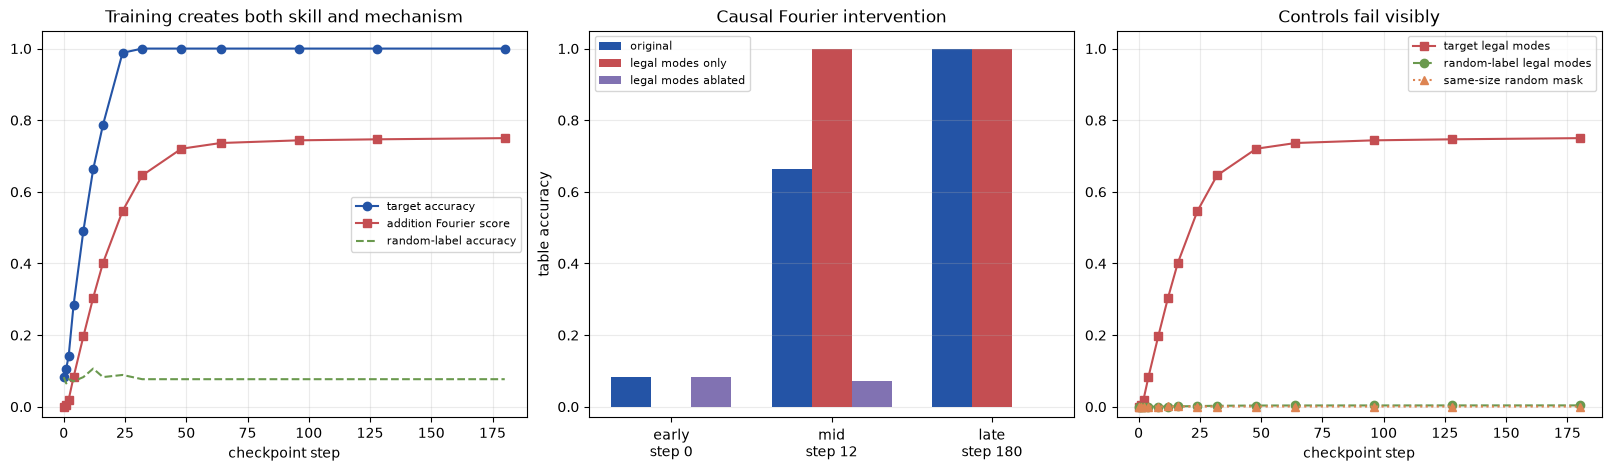

In [12]:
def plot_checkpoint_archaeology_signature(result: dict, *, save_path: Path | None = None):
    """Create the three-panel learner-facing signature figure."""

    import matplotlib.pyplot as plt

    steps = result["checkpoint_steps"]
    target_acc = result["target_accuracy_trajectory"]
    target_fourier = result["target_addition_fourier_score_trajectory"]
    random_label_acc = result["random_label_accuracy_trajectory"]
    random_label_fourier = result["random_label_addition_fourier_score_trajectory"]
    random_mask_score = result["target_random_fourier_score_trajectory"]
    intervention_rows = result["intervention_rows"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)

    axes[0].plot(steps, target_acc, marker="o", label="target accuracy", color="#2454a6")
    axes[0].plot(steps, target_fourier, marker="s", label="addition Fourier score", color="#c44e52")
    axes[0].plot(steps, random_label_acc, linestyle="--", label="random-label accuracy", color="#6a994e")
    axes[0].set_title("Training creates both skill and mechanism")
    axes[0].set_xlabel("checkpoint step")
    axes[0].set_ylim(-0.03, 1.05)
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=8)

    labels = [row["phase"] for row in intervention_rows]
    x = list(range(len(labels)))
    width = 0.25
    axes[1].bar(
        [value - width for value in x],
        [row["original_accuracy"] for row in intervention_rows],
        width=width,
        label="original",
        color="#2454a6",
    )
    axes[1].bar(
        x,
        [row["legal_only_accuracy"] for row in intervention_rows],
        width=width,
        label="legal modes only",
        color="#c44e52",
    )
    axes[1].bar(
        [value + width for value in x],
        [row["legal_ablated_accuracy"] for row in intervention_rows],
        width=width,
        label="legal modes ablated",
        color="#8172b2",
    )
    axes[1].set_title("Causal Fourier intervention")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f"{row['phase']}\nstep {row['step']}" for row in intervention_rows])
    axes[1].set_ylim(-0.03, 1.05)
    axes[1].set_ylabel("table accuracy")
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].legend(fontsize=8)

    axes[2].plot(steps, target_fourier, marker="s", label="target legal modes", color="#c44e52")
    axes[2].plot(
        steps,
        random_label_fourier,
        marker="o",
        linestyle="--",
        label="random-label legal modes",
        color="#6a994e",
    )
    axes[2].plot(
        steps,
        random_mask_score,
        marker="^",
        linestyle=":",
        label="same-size random mask",
        color="#dd8452",
    )
    axes[2].set_title("Controls fail visibly")
    axes[2].set_xlabel("checkpoint step")
    axes[2].set_ylim(-0.03, 1.05)
    axes[2].grid(alpha=0.25)
    axes[2].legend(fontsize=8)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
    return fig

def metrics_table_markdown(metrics_table: list[dict]) -> str:
    rows = ["| quantity | value | control / threshold | pass |", "|---|---:|---|---|"]
    for row in metrics_table:
        rows.append(
            f"| {row['quantity']} | {row['value']:.4f} | {row['control_or_threshold']} | "
            f"{'yes' if row['passed'] else 'no'} |"
        )
    return "\n".join(rows)

def checkpoint_emergence_smoke_test() -> dict:
    steps, trajectories = toy_training_trajectories()
    return _report_dict(
        mechanism_emergence_report(
            steps,
            trajectories["autoregressive"],
            metric_name="induction_probe_accuracy",
            threshold=0.6,
            min_consecutive=2,
        )
    )

def phase_transition_smoke_test() -> dict:
    steps, trajectories = toy_training_trajectories()
    return _report_dict(
        phase_transition_report(
            steps,
            trajectories["autoregressive"],
            metric_name="induction_probe_accuracy",
            min_jump=0.3,
        )
    )

def random_control_smoke_test() -> dict:
    _, trajectories = toy_training_trajectories()
    return _report_dict(
        random_control_report(
            trajectories["random_control"],
            metric_name="label_shuffled_probe",
            max_allowed_value=0.2,
        )
    )

def developmental_comparison_smoke_test() -> dict:
    steps, trajectories = toy_training_trajectories()
    return _report_dict(
        developmental_comparison_report(
            steps,
            trajectories,
            threshold=0.6,
            min_consecutive=2,
        )
    )

def live_checkpoint_archaeology_smoke_test(
    checkpoint_root: Path | None = None,
    *,
    device: str | t.device = "cpu",
    seed: int = 0,
) -> dict:
    return checkpoint_archaeology_signature_result(
        checkpoint_root=checkpoint_root,
        device=device,
        seed=seed,
        include_figure=False,
    )

def run_smoke_test(cpu: bool = True) -> dict:
    _ = cpu
    return {
        "checkpoint_emergence": checkpoint_emergence_smoke_test(),
        "phase_transition": phase_transition_smoke_test(),
        "random_control": random_control_smoke_test(),
        "developmental_comparison": developmental_comparison_smoke_test(),
        "live_checkpoint_archaeology": live_checkpoint_archaeology_smoke_test(device="cpu"),
    }

def run_modular_addition_checkpoint_archaeology_preflight(
    max_vram_gb: float = 24.0,
) -> dict:
    """CUDA wrapper used by the parent serial validation path."""

    if not t.cuda.is_available():
        raise RuntimeError("Checkpoint archaeology GPU verification requires CUDA.")

    t.cuda.reset_peak_memory_stats()
    result = checkpoint_archaeology_signature_result(device="cuda", include_figure=False)
    t.cuda.synchronize()
    peak_vram_gb = t.cuda.max_memory_allocated() / 1024**3
    result.update(
        {
            "cuda_available": True,
            "device": t.cuda.get_device_name(0),
            "torch_version": t.__version__,
            "cuda_version": t.version.cuda,
            "gpu_total_memory_gb": t.cuda.get_device_properties(0).total_memory / 1024**3,
            "peak_vram_gb": peak_vram_gb,
            "within_vram_budget": peak_vram_gb <= max_vram_gb,
        }
    )
    result["preflight_passed"] = bool(result["preflight_passed"] and result["within_vram_budget"])
    return result

def run_gpu_test(max_vram_gb: float = 24.0) -> dict:
    return run_modular_addition_checkpoint_archaeology_preflight(max_vram_gb=max_vram_gb)

def run_full_experiment(max_vram_gb: float = 24.0) -> dict:
    return run_gpu_test(max_vram_gb=max_vram_gb)

figure_path = assets_dir / "checkpoint_archaeology_signature_result.png"
fig = plot_checkpoint_archaeology_signature(signature_result, save_path=figure_path)
display(Markdown(metrics_table_markdown(signature_result["metrics_table"])))
assert figure_path.exists() and figure_path.stat().st_size > 20_000
print(f"Wrote notebook-generated signature figure to {figure_path}")

<details>
<summary>Expected output</summary>

```text
Wrote notebook-generated signature figure to .../checkpoint_archaeology_signature_result.png
```

<img src="../../instructions/assets/checkpoint_archaeology_signature_result.png" width="900">

</details>

<details>
<summary>Help</summary>

Do not load a figure from `verification_report.json`. Plot directly from `signature_result`: checkpoint trajectories in panel 1, intervention bars in panel 2, and random-label/random-mask control curves in panel 3.

</details>

<details>
<summary>Interpretation</summary>

This is the notebook signature result. A reviewer should be able to understand the claim from this figure and the metrics table without reading any appendix report.

</details>

<details>
<summary>Solution</summary>

```python
def plot_checkpoint_archaeology_signature(result: dict, *, save_path: Path | None = None):
    """Create the three-panel learner-facing signature figure."""

    import matplotlib.pyplot as plt

    steps = result["checkpoint_steps"]
    target_acc = result["target_accuracy_trajectory"]
    target_fourier = result["target_addition_fourier_score_trajectory"]
    random_label_acc = result["random_label_accuracy_trajectory"]
    random_label_fourier = result["random_label_addition_fourier_score_trajectory"]
    random_mask_score = result["target_random_fourier_score_trajectory"]
    intervention_rows = result["intervention_rows"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)

    axes[0].plot(steps, target_acc, marker="o", label="target accuracy", color="#2454a6")
    axes[0].plot(steps, target_fourier, marker="s", label="addition Fourier score", color="#c44e52")
    axes[0].plot(steps, random_label_acc, linestyle="--", label="random-label accuracy", color="#6a994e")
    axes[0].set_title("Training creates both skill and mechanism")
    axes[0].set_xlabel("checkpoint step")
    axes[0].set_ylim(-0.03, 1.05)
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=8)

    labels = [row["phase"] for row in intervention_rows]
    x = list(range(len(labels)))
    width = 0.25
    axes[1].bar(
        [value - width for value in x],
        [row["original_accuracy"] for row in intervention_rows],
        width=width,
        label="original",
        color="#2454a6",
    )
    axes[1].bar(
        x,
        [row["legal_only_accuracy"] for row in intervention_rows],
        width=width,
        label="legal modes only",
        color="#c44e52",
    )
    axes[1].bar(
        [value + width for value in x],
        [row["legal_ablated_accuracy"] for row in intervention_rows],
        width=width,
        label="legal modes ablated",
        color="#8172b2",
    )
    axes[1].set_title("Causal Fourier intervention")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f"{row['phase']}\nstep {row['step']}" for row in intervention_rows])
    axes[1].set_ylim(-0.03, 1.05)
    axes[1].set_ylabel("table accuracy")
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].legend(fontsize=8)

    axes[2].plot(steps, target_fourier, marker="s", label="target legal modes", color="#c44e52")
    axes[2].plot(
        steps,
        random_label_fourier,
        marker="o",
        linestyle="--",
        label="random-label legal modes",
        color="#6a994e",
    )
    axes[2].plot(
        steps,
        random_mask_score,
        marker="^",
        linestyle=":",
        label="same-size random mask",
        color="#dd8452",
    )
    axes[2].set_title("Controls fail visibly")
    axes[2].set_xlabel("checkpoint step")
    axes[2].set_ylim(-0.03, 1.05)
    axes[2].grid(alpha=0.25)
    axes[2].legend(fontsize=8)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
    return fig

def metrics_table_markdown(metrics_table: list[dict]) -> str:
    rows = ["| quantity | value | control / threshold | pass |", "|---|---:|---|---|"]
    for row in metrics_table:
        rows.append(
            f"| {row['quantity']} | {row['value']:.4f} | {row['control_or_threshold']} | "
            f"{'yes' if row['passed'] else 'no'} |"
        )
    return "\n".join(rows)

def checkpoint_emergence_smoke_test() -> dict:
    steps, trajectories = toy_training_trajectories()
    return _report_dict(
        mechanism_emergence_report(
            steps,
            trajectories["autoregressive"],
            metric_name="induction_probe_accuracy",
            threshold=0.6,
            min_consecutive=2,
        )
    )

def phase_transition_smoke_test() -> dict:
    steps, trajectories = toy_training_trajectories()
    return _report_dict(
        phase_transition_report(
            steps,
            trajectories["autoregressive"],
            metric_name="induction_probe_accuracy",
            min_jump=0.3,
        )
    )

def random_control_smoke_test() -> dict:
    _, trajectories = toy_training_trajectories()
    return _report_dict(
        random_control_report(
            trajectories["random_control"],
            metric_name="label_shuffled_probe",
            max_allowed_value=0.2,
        )
    )

def developmental_comparison_smoke_test() -> dict:
    steps, trajectories = toy_training_trajectories()
    return _report_dict(
        developmental_comparison_report(
            steps,
            trajectories,
            threshold=0.6,
            min_consecutive=2,
        )
    )

def live_checkpoint_archaeology_smoke_test(
    checkpoint_root: Path | None = None,
    *,
    device: str | t.device = "cpu",
    seed: int = 0,
) -> dict:
    return checkpoint_archaeology_signature_result(
        checkpoint_root=checkpoint_root,
        device=device,
        seed=seed,
        include_figure=False,
    )

def run_smoke_test(cpu: bool = True) -> dict:
    _ = cpu
    return {
        "checkpoint_emergence": checkpoint_emergence_smoke_test(),
        "phase_transition": phase_transition_smoke_test(),
        "random_control": random_control_smoke_test(),
        "developmental_comparison": developmental_comparison_smoke_test(),
        "live_checkpoint_archaeology": live_checkpoint_archaeology_smoke_test(device="cpu"),
    }

def run_modular_addition_checkpoint_archaeology_preflight(
    max_vram_gb: float = 24.0,
) -> dict:
    """CUDA wrapper used by the parent serial validation path."""

    if not t.cuda.is_available():
        raise RuntimeError("Checkpoint archaeology GPU verification requires CUDA.")

    t.cuda.reset_peak_memory_stats()
    result = checkpoint_archaeology_signature_result(device="cuda", include_figure=False)
    t.cuda.synchronize()
    peak_vram_gb = t.cuda.max_memory_allocated() / 1024**3
    result.update(
        {
            "cuda_available": True,
            "device": t.cuda.get_device_name(0),
            "torch_version": t.__version__,
            "cuda_version": t.version.cuda,
            "gpu_total_memory_gb": t.cuda.get_device_properties(0).total_memory / 1024**3,
            "peak_vram_gb": peak_vram_gb,
            "within_vram_budget": peak_vram_gb <= max_vram_gb,
        }
    )
    result["preflight_passed"] = bool(result["preflight_passed"] and result["within_vram_budget"])
    return result

def run_gpu_test(max_vram_gb: float = 24.0) -> dict:
    return run_modular_addition_checkpoint_archaeology_preflight(max_vram_gb=max_vram_gb)

def run_full_experiment(max_vram_gb: float = 24.0) -> dict:
    return run_gpu_test(max_vram_gb=max_vram_gb)
```

</details>

## Try It Yourself

Change `PLAY_SEED`, the random-mask seed, or the mechanism threshold. The expected qualitative result is not that every seed has the identical curve; it is that target training solves the finite table, the legal Fourier score becomes large, and the controls remain weak.

In [13]:
PLAY_SEED = 1
PLAY_RANDOM_MASK_SEED = 19
PLAY_THRESHOLD = 0.55

with tempfile.TemporaryDirectory(prefix="arena17_play_") as tmp:
    play_result = checkpoint_archaeology_signature_result(
        checkpoint_root=Path(tmp),
        device="cpu",
        seed=PLAY_SEED,
        include_figure=False,
    )

print("final accuracy:", round(play_result["final_accuracy"], 4))
print("final addition Fourier score:", round(play_result["final_addition_fourier_score"], 4))
print("mechanism stable from:", play_result["mechanism_stable_from_step"])
print("random-label peak accuracy:", round(play_result["random_label_peak_accuracy"], 4))
print("late intervention:")
for key, value in play_result["intervention_rows"][-1].items():
    print(f"  {key}: {value}")

final accuracy: 1.0
final addition Fourier score: 0.7253
mechanism stable from: 32
random-label peak accuracy: 0.1302
late intervention:
  phase: late
  step: 180
  original_accuracy: 1.0
  addition_fourier_score: 0.7252681255340576
  random_fourier_score: 0.0007011870620772243
  legal_only_accuracy: 1.0
  legal_ablated_accuracy: 0.0
  random_only_accuracy: 0.0710059180855751
  random_ablated_accuracy: 1.0
  legal_ablation_drop: 1.0
  random_ablation_drop: 0.0


## Anomaly Hunting

Try to find a seed where accuracy reaches 1.0 but the final addition Fourier score is unusually low. If you find one, inspect the late intervention table before changing the claim. A perfect classifier can contain extra non-mechanism logit power; the causal question is whether the legal modes are sufficient and whether ablating them destroys the rule.

Other useful attacks:

- lower the hidden dimension and see whether the mechanism score becomes less stable;
- increase the random-label training steps and confirm it still fails on the true table;
- loosen the mechanism threshold and check whether random masks start passing;
- compare the first accuracy crossing with the first mechanism crossing.

## Limitations

This notebook proves a bounded model-organism claim. It exhaustively evaluates the finite mod-13 table, but it does not claim OOD arithmetic generalization, large-model checkpoint archaeology, or that every learned algorithm must be Fourier sparse. The intervention is causal in logit-table Fourier space, not an activation patch in a transformer block.

That scope is intentional. The value of 17.1 is the discipline: state a concrete mechanism metric, validate it on exact ground truth, save and reload checkpoints, run negative controls, and only then narrate emergence.

## Reading Links

- Original ARENA [1.5.2] Grokking and Modular Arithmetic, for the deeper transformer/Fourier reverse-engineering arc.
- Nanda et al., Progress measures for grokking via mechanistic interpretability.
- Toy-model checkpoint studies are useful when the mechanism metric has an exact oracle and a failing control.

## Appendix: Verification Report Is Support, Not The Lesson

The parent validation runner can execute `run_gpu_test(max_vram_gb=24.0)` serially. This notebook does not need CUDA to teach the core mechanism, and this child task intentionally does not launch GPU jobs.

In [14]:
tests.test_notebook_contract(run_smoke_test)
# Parent serial validation may run this later on CUDA:
# cuda_result = run_gpu_test(max_vram_gb=24.0)

All tests in `test_notebook_contract` passed!
